In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict):
    number1: int
    number2: int
    number3: int
    number4: int
    operation: str
    operation2: str
    finalNumber: int
    finalNumber2: int

In [8]:
def adder_node(state: AgentState) -> AgentState:
    """ Healthy Habit """
    
    state["finalNumber"] = state["number1"] + state["number2"]
    return state

def adder_node2(state: AgentState) -> AgentState:
    """ Healthy Habit """
    
    state["finalNumber2"] = state["number3"] + state["number4"]
    return state
    
def substract_node(state: AgentState) -> AgentState:
    """ Healthy Habit """
    
    state["finalNumber"] = state["number1"] - state["number2"]
    return state

def substract_node2(state: AgentState) -> AgentState:
    """ Healthy Habit """
    
    state["finalNumber2"] = state["number3"] - state["number4"]
    return state

def route_node(state: AgentState) -> AgentState:
    """ Healthy Habit """

    if state["operation"] == "+":
        return "add_operation" #edges

    elif state["operation"] == "-":
        return "substract_operation" #edges

def route_node2(state: AgentState) -> AgentState:
    """ Healthy Habit """

    if state["operation2"] == "+":
        return "add_operation2" #edges

    elif state["operation2"] == "-":
        return "substract_operation2" #edges

In [9]:
graph = StateGraph(AgentState)

graph.add_node("adder_node",adder_node)
graph.add_node("substract_node",substract_node)
graph.add_node("route_node",lambda state:state)

graph.add_node("adder_node2",adder_node2)
graph.add_node("substract_node2",substract_node2)
graph.add_node("route_node2",lambda state:state)

graph.add_edge(START, "route_node")

graph.add_conditional_edges(
    "route_node",
    route_node,
    {
        #Edge: Node
        "add_operation": "adder_node",
        "substract_operation": "substract_node"
    }
)
graph.add_edge("adder_node","route_node2")
graph.add_edge("substract_node","route_node2")

graph.add_conditional_edges(
    "route_node2",
    route_node2,
    {
        #Edge: Node
        "add_operation2": "adder_node2",
        "substract_operation2": "substract_node2"
    }
)

graph.add_edge("adder_node2",END)
graph.add_edge("substract_node2",END)

app = graph.compile()

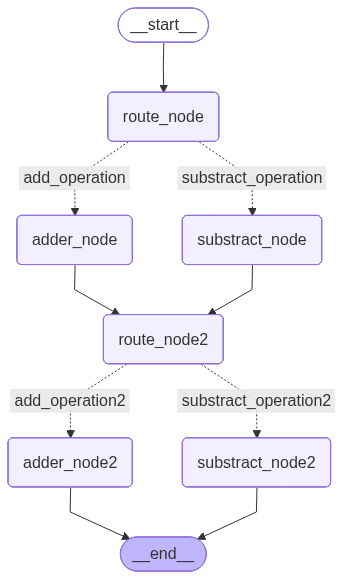

In [10]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [11]:
result = app.invoke({
    "number1": 10,
    "number2": 5,
    "number3": 2,
    "number4": 1,
    "operation": "+",
    "operation2": "-"
})

print(result)

{'number1': 10, 'number2': 5, 'number3': 2, 'number4': 1, 'operation': '+', 'operation2': '-', 'finalNumber': 15, 'finalNumber2': 1}
